# 14-statement-clustering

### 1. Загрузите картинку parrots.jpg

Размер изображения: (474, 713, 3)
Тип данных: float64
Диапазон значений: [0.00, 1.00]


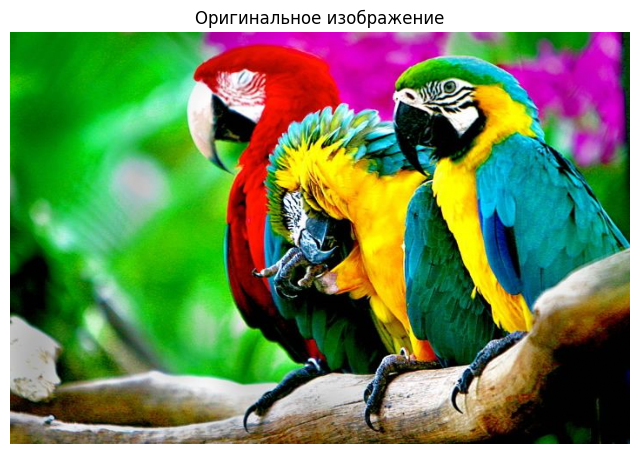

In [14]:
import numpy as np
from skimage.io import imread
from skimage import img_as_float
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/Sazankova/parrot/main/parrots.jpg'
image = imread(url)


image = img_as_float(image)

print(f"Размер изображения: {image.shape}")
print(f"Тип данных: {image.dtype}")
print(f"Диапазон значений: [{image.min():.2f}, {image.max():.2f}]")


plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.title('Оригинальное изображение')
plt.axis('off')
plt.show()

### 2. Создайте матрицу объекты-признаки

In [15]:
h, w, channels = image.shape

# Преобразуем в матрицу (n_pixels x 3)
pixels = image.reshape(-1, 3)
print(f"Количество пикселей: {len(pixels)}")
print(f"Форма матрицы признаков: {pixels.shape}")


Количество пикселей: 337962
Форма матрицы признаков: (337962, 3)


### 3. Функция для вычисления PSNR

In [16]:
def psnr(original, compressed):
    """
    Вычисляет Peak Signal-to-Noise Ratio между двумя изображениями
    """
    mse = np.mean((original - compressed) ** 2)
    if mse == 0:
        return float('inf')
    max_pixel = 1.0  # изображение нормализовано к [0, 1]
    psnr_value = 20 * np.log10(max_pixel / np.sqrt(mse))
    return psnr_value

### 4. Функция кластеризации и восстановления изображения


In [17]:
def cluster_and_reconstruct(pixels, original_shape, n_clusters, method='mean'):
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=241)
    labels = kmeans.fit_predict(pixels)
    centers = kmeans.cluster_centers_
    reconstructed = np.zeros_like(pixels)
    
    if method == 'mean':
        # Заполняем средним цветом по кластеру
        for i in range(n_clusters):
            cluster_mask = (labels == i)
            reconstructed[cluster_mask] = centers[i]
    else:  # median
        # Заполняем медианным цветом по кластеру
        for i in range(n_clusters):
            cluster_mask = (labels == i)
            cluster_pixels = pixels[cluster_mask]
            if len(cluster_pixels) > 0:
                reconstructed[cluster_mask] = np.median(cluster_pixels, axis=0)
    
    return reconstructed.reshape(original_shape), labels, centers

### 5. Поиск минимального количества кластеров с PSNR > 20

In [18]:
n_clusters_range = range(2, 21)
psnr_mean_values = []
psnr_median_values = []

best_mean = None
best_median = None

print("Поиск оптимального количества кластеров...")
print("-" * 60)

for n in n_clusters_range:
    print(f"\nКоличество кластеров: {n}")
    
    # Восстановление со средним
    recon_mean, _, _ = cluster_and_reconstruct(pixels, image.shape, n, 'mean')
    psnr_mean = psnr(image, recon_mean)
    psnr_mean_values.append(psnr_mean)
    
    # Восстановление с медианой
    recon_median, _, _ = cluster_and_reconstruct(pixels, image.shape, n, 'median')
    psnr_median = psnr(image, recon_median)
    psnr_median_values.append(psnr_median)
    
    print(f"  PSNR (mean):   {psnr_mean:.2f}")
    print(f"  PSNR (median): {psnr_median:.2f}")
    
    # Проверка условия PSNR > 20
    if best_mean is None and psnr_mean > 20:
        best_mean = n
        print(f"  --> Для mean: PSNR > 20 достигнуто при {n} кластерах")
    
    if best_median is None and psnr_median > 20:
        best_median = n
        print(f"  --> Для median: PSNR > 20 достигнуто при {n} кластерах")

Поиск оптимального количества кластеров...
------------------------------------------------------------

Количество кластеров: 2
  PSNR (mean):   12.11
  PSNR (median): 11.69

Количество кластеров: 3
  PSNR (mean):   13.17
  PSNR (median): 12.63

Количество кластеров: 4
  PSNR (mean):   14.32
  PSNR (median): 14.00

Количество кластеров: 5
  PSNR (mean):   15.09
  PSNR (median): 14.69

Количество кластеров: 6
  PSNR (mean):   16.57
  PSNR (median): 16.07

Количество кластеров: 7
  PSNR (mean):   17.67
  PSNR (median): 17.37

Количество кластеров: 8
  PSNR (mean):   18.38
  PSNR (median): 18.10

Количество кластеров: 9
  PSNR (mean):   19.14
  PSNR (median): 18.84

Количество кластеров: 10
  PSNR (mean):   19.54
  PSNR (median): 19.23

Количество кластеров: 11
  PSNR (mean):   20.08
  PSNR (median): 19.83
  --> Для mean: PSNR > 20 достигнуто при 11 кластерах

Количество кластеров: 12
  PSNR (mean):   20.58
  PSNR (median): 20.32
  --> Для median: PSNR > 20 достигнуто при 12 кластерах

К

# 6. Визуализация результатов

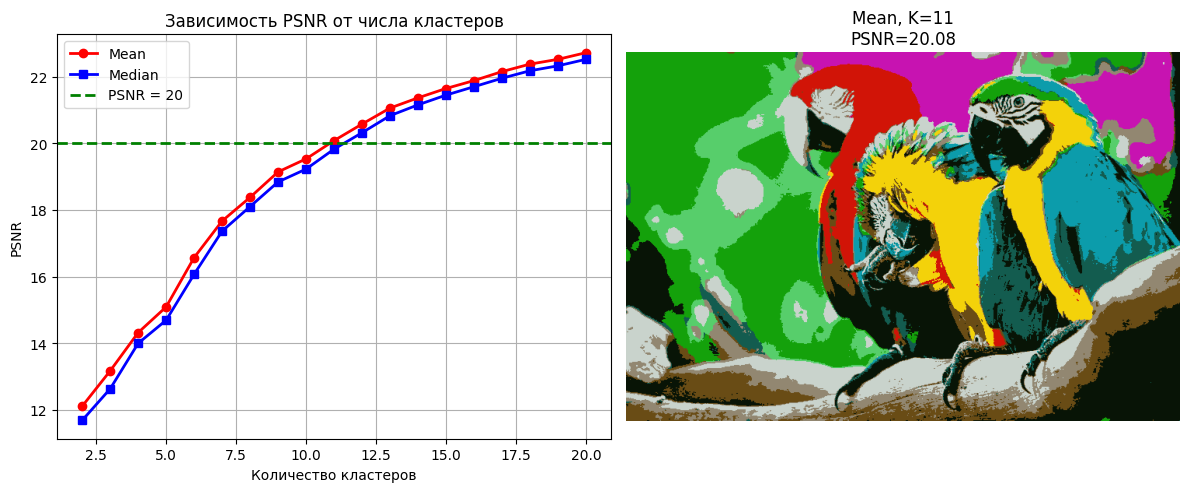

In [19]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(n_clusters_range, psnr_mean_values, 'ro-', linewidth=2, label='Mean')
plt.plot(n_clusters_range, psnr_median_values, 'bs-', linewidth=2, label='Median')
plt.axhline(y=20, color='g', linestyle='--', linewidth=2, label='PSNR = 20')
plt.xlabel('Количество кластеров')
plt.ylabel('PSNR')
plt.title('Зависимость PSNR от числа кластеров')
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)
if best_mean:
    best_recon, _, _ = cluster_and_reconstruct(pixels, image.shape, best_mean, 'mean')
    plt.imshow(best_recon)
    plt.title(f'Mean, K={best_mean}\nPSNR={psnr_mean_values[best_mean-2]:.2f}')
elif best_median:
    best_recon, _, _ = cluster_and_reconstruct(pixels, image.shape, best_median, 'median')
    plt.imshow(best_recon)
    plt.title(f'Median, K={best_median}\nPSNR={psnr_median_values[best_median-2]:.2f}')
plt.axis('off')

plt.tight_layout()
plt.show()

# 7. Финальный ответ

In [20]:
print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ")
print("="*50)

print(f"\nМинимальное количество кластеров для PSNR > 20:")
print(f"  - С заполнением средним (mean):   {best_mean}")
print(f"  - С заполнением медианой (median): {best_median}")

# В качестве ответа обычно берут лучший результат (меньшее число кластеров)
final_answer = min(best_mean, best_median) if (best_mean and best_median) else (best_mean or best_median)
print(f"\nОТВЕТ НА ЗАДАНИЕ: {final_answer}")


РЕЗУЛЬТАТЫ

Минимальное количество кластеров для PSNR > 20:
  - С заполнением средним (mean):   11
  - С заполнением медианой (median): 12

ОТВЕТ НА ЗАДАНИЕ: 11
